# 🐒 Animal Species Recognition Framework
## A Comparative and Explainable CNN Study: Custom CNN vs VGG16 vs ResNet50

**Student:** Mani Teja Padala | **ID:** 69767331
**Course:** Machine Learning — DSC01
**Dataset:** 10 Monkey Species (Kaggle)

This notebook trains and compares three CNN models to recognise 10 monkey species from images:
1. **Custom CNN** — built from scratch
2. **VGG16** — transfer learning (ImageNet)
3. **ResNet50** — transfer learning (ImageNet)

Models are evaluated with accuracy, precision, recall (macro), F1, confusion matrices, ROC/AUC (one-vs-rest), and computational efficiency. Grad-CAM is used for explainability.

> **Setup on Kaggle:** Add the dataset **"10 Monkey Species"** (slothkong/10-monkey-species) via *+ Add Input*. Settings → Accelerator → **GPU**. Settings → Internet → **On** (needed to download ImageNet weights).

## Step 1: Imports & Configuration

In [27]:
import os, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_CNN = 15
EPOCHS_TL = 10
LR_CNN = 1e-3
LR_TL = 1e-4

print('TensorFlow', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Locate Dataset (auto-detect Kaggle paths)

In [28]:
# The 10 Monkey Species dataset has 'training' and 'validation' folders.
# We auto-detect them so paths work regardless of exact mount location.
def find_dir(name_options, search_root='/kaggle/input'):
    for root, dirs, _ in os.walk(search_root):
        for d in dirs:
            if d.lower() in name_options:
                return os.path.join(root, d)
    return None

TRAIN_DIR = find_dir({'training', 'train'})
TEST_DIR  = find_dir({'validation', 'val', 'valid'})

print('Train dir:', TRAIN_DIR)
print('Test  dir:', TEST_DIR)
assert TRAIN_DIR and TEST_DIR, 'Could not find dataset folders. Add the 10 Monkey Species dataset as input.'

# Some versions nest one more level (training/training). Handle that:
def maybe_descend(p):
    subs = [d for d in os.listdir(p) if os.path.isdir(os.path.join(p, d))]
    if len(subs) == 1 and subs[0].lower() in {'training','validation','train','val'}:
        return os.path.join(p, subs[0])
    return p
TRAIN_DIR = maybe_descend(TRAIN_DIR)
TEST_DIR  = maybe_descend(TEST_DIR)

CLASSES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
NUM_CLASSES = len(CLASSES)
print('Classes (%d):' % NUM_CLASSES, CLASSES)

Train dir: /kaggle/input/datasets/slothkong/10-monkey-species/training
Test  dir: /kaggle/input/datasets/slothkong/10-monkey-species/validation
Classes (10): ['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']


## Step 3: Class Distribution & Sample Images
We inspect how many images each species has, and view a few examples.

    Train  Test
n0    105    26
n1    111    28
n2    110    27
n3    122    30
n4    105    26
n5    113    28
n6    106    26
n7    114    28
n8    106    27
n9    106    26

Total train: 1098 | Total test: 272


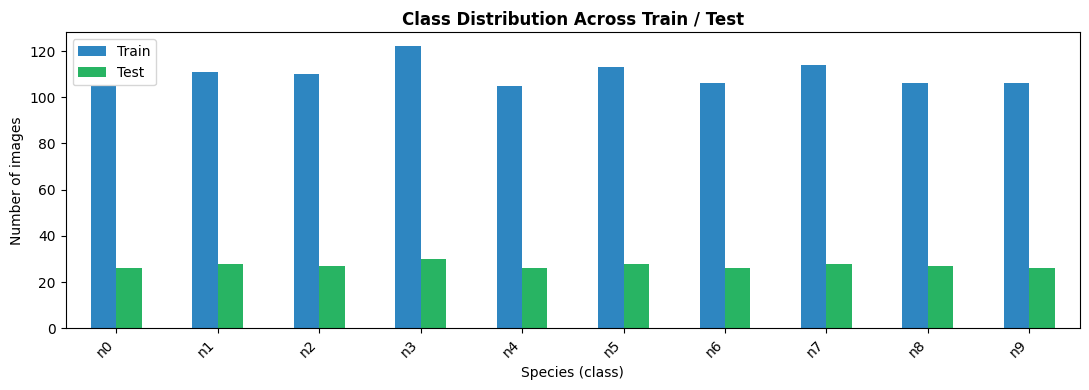

In [29]:
# Count images per class
counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASSES}
test_counts = {c: len(os.listdir(os.path.join(TEST_DIR, c))) for c in CLASSES}

dist = pd.DataFrame({'Train': counts, 'Test': test_counts})
print(dist)
print('\nTotal train:', dist['Train'].sum(), '| Total test:', dist['Test'].sum())

fig, ax = plt.subplots(figsize=(11,4))
dist.plot(kind='bar', ax=ax, color=['#2E86C1', '#28B463'])
ax.set_title('Class Distribution Across Train / Test', fontweight='bold')
ax.set_ylabel('Number of images'); ax.set_xlabel('Species (class)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight'); plt.show()

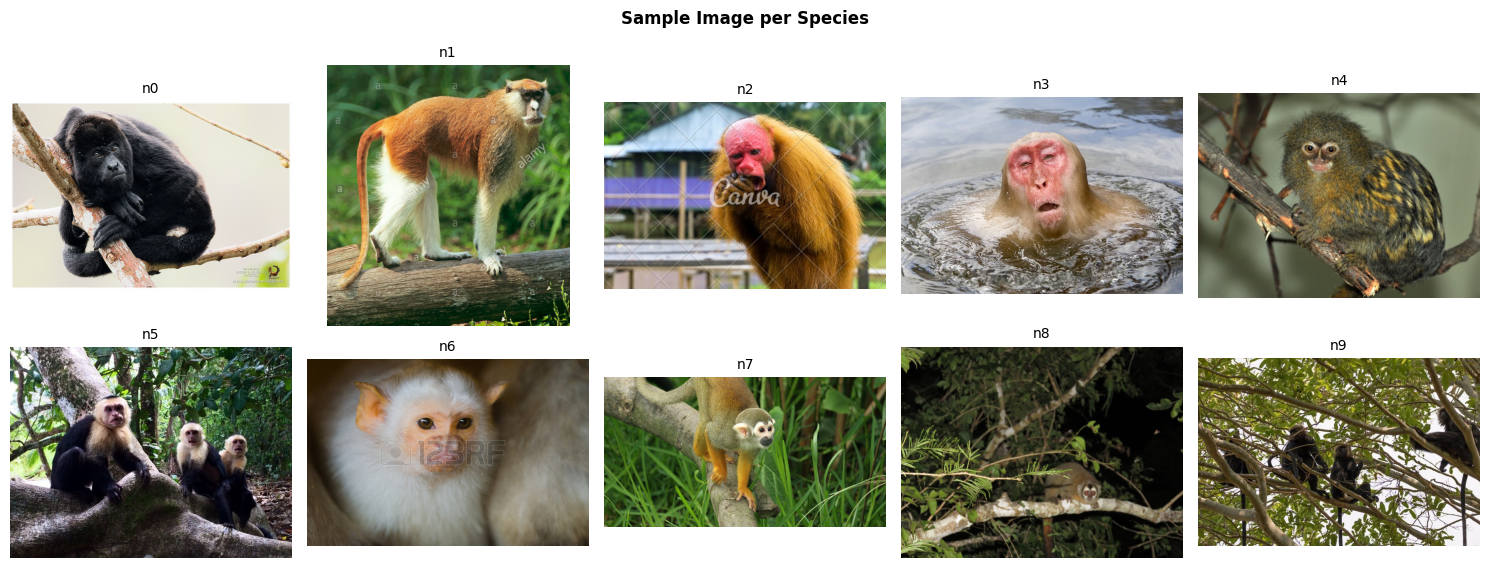

In [30]:
# Show one sample image per class
import matplotlib.image as mpimg
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, c in zip(axes.ravel(), CLASSES):
    folder = os.path.join(TRAIN_DIR, c)
    img_name = os.listdir(folder)[0]
    ax.imshow(mpimg.imread(os.path.join(folder, img_name)))
    ax.set_title(c, fontsize=10); ax.axis('off')
plt.suptitle('Sample Image per Species', fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight'); plt.show()

## Step 4: Data Generators (Preprocessing + Augmentation)
Training images are augmented (rotation, shift, zoom, flip, brightness) to improve generalisation. Validation/test images are only rescaled. We hold out 15% of the training folder as a validation split, and keep the dataset's own `validation` folder as the independent **test** set.

In [31]:
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.15,
)
test_gen_aug = ImageDataGenerator(rescale=1./255)

train_generator = train_aug.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42, classes=CLASSES)

val_generator = train_aug.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, classes=CLASSES)

test_generator = test_gen_aug.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False, classes=CLASSES)

print('Train batches:', len(train_generator),
      '| Val batches:', len(val_generator),
      '| Test batches:', len(test_generator))

Found 940 images belonging to 10 classes.
Found 158 images belonging to 10 classes.
Found 272 images belonging to 10 classes.
Train batches: 30 | Val batches: 5 | Test batches: 9


## Step 5: Reusable Training Plot & Evaluation Functions

In [32]:
def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['accuracy'], label='Train', color='#1DB954', lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Val', color='#2E75B6', lw=2, ls='--')
    axes[0].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
    axes[1].plot(history.history['loss'], label='Train', color='#E74C3C', lw=2)
    axes[1].plot(history.history['val_loss'], label='Val', color='#E67E22', lw=2, ls='--')
    axes[1].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
    plt.tight_layout()
    fname = f'{model_name.replace(" ","_").lower()}_curves.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight'); plt.show()

def evaluate_model(model, gen, model_name):
    gen.reset()
    y_prob = model.predict(gen, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = gen.classes

    acc = np.mean(y_pred == y_true)
    report = classification_report(y_true, y_pred, target_names=CLASSES,
                                   output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall    = report['macro avg']['recall']
    f1        = report['macro avg']['f1-score']

    # One-vs-rest macro AUC
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    try:
        macro_auc = auc(*roc_curve(y_true_bin.ravel(), y_prob.ravel())[:2])
    except Exception:
        macro_auc = float('nan')

    print(f'\n=== {model_name} ===')
    print(f'  Accuracy:        {acc:.4f}')
    print(f'  Precision (macro): {precision:.4f}')
    print(f'  Recall (macro):    {recall:.4f}')
    print(f'  F1 (macro):        {f1:.4f}')
    print(f'  AUC (micro OvR):   {macro_auc:.4f}')

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    fname = f'{model_name.replace(" ","_").lower()}_confusion.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight'); plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': precision,
            'recall': recall, 'f1_score': f1, 'auc': macro_auc,
            'y_true': y_true, 'y_prob': y_prob}

## Step 6: Model 1 — Custom CNN (from scratch)

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,050 (2.01 MB)

 Trainable params: 526,090 (2.01 MB)

 Non-trainable params: 960 (3.75 KB)

Training Custom CNN...
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 989ms/step - accuracy: 0.2723 - loss: 2.0987 - val_accuracy: 0.1266 - val_loss: 2.3736 - learning_rate: 0.0010
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 872ms/step - accuracy: 0.3766 - loss: 1.7404 - val_accuracy: 0.0949 - val_loss: 2.8778 - learning_rate: 0.0010
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 868ms/step - accuracy: 0.4340 - loss: 1.6354 - val_accuracy: 0.1013 - val_loss: 3.7740 - learning_rate: 0.0010
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 848ms/step - accuracy: 0.4468 - loss: 1.5469 - val_accuracy: 0.0949 - val_loss: 4.6358 - learning_rate: 0.0010
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 887ms/step - accuracy: 0.4798 - loss: 1.4201 - val_accuracy: 0.0949 - val_loss: 5.2408 - learning_rate: 5.0000e-04
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 875ms/step - accuracy: 0.4862 - loss: 1.4139 - val_accuracy: 0.0949 - val_loss: 5.2121 - learning_rate: 5.0000e-04


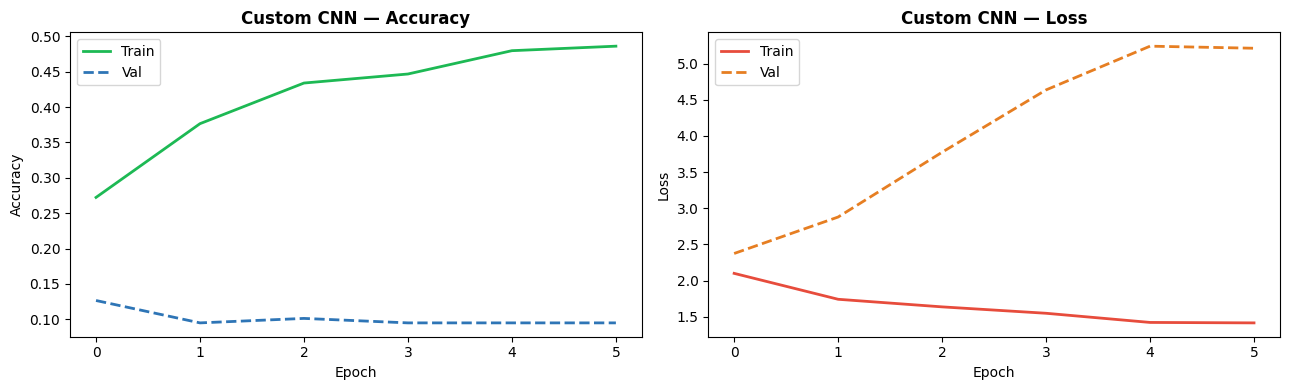


=== Custom CNN ===
  Accuracy:        0.1103
  Precision (macro): 0.0487
  Recall (macro):    0.1082
  F1 (macro):        0.0571
  AUC (micro OvR):   0.5396


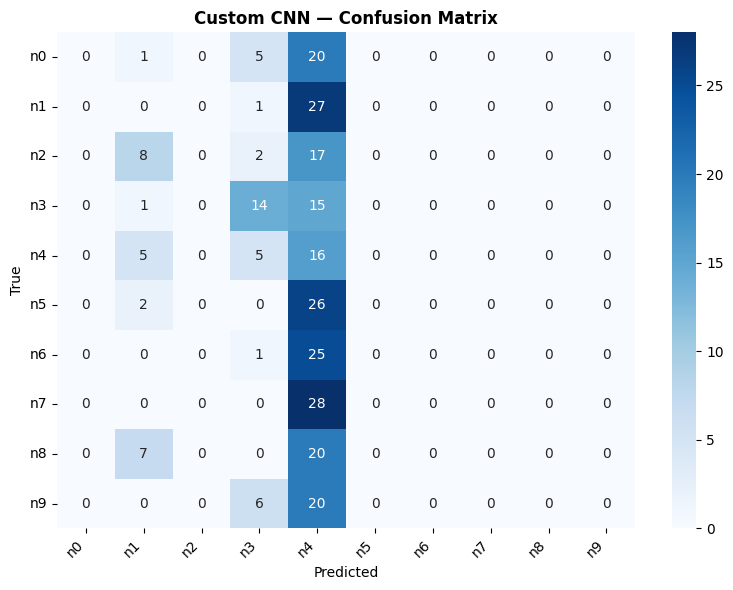

In [33]:
def build_custom_cnn():
    model = keras.Sequential([
        layers.Input((224, 224, 3)),
        layers.Conv2D(32, 3, padding='same', activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(256, 3, padding='same', activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'), layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name='Custom_CNN')
    return model

cnn = build_custom_cnn()
cnn.compile(optimizer=keras.optimizers.Adam(LR_CNN),
            loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

cnn_cb = [callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
          callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss'),
          callbacks.ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True)]

print('Training Custom CNN...')
cnn_hist = cnn.fit(train_generator, validation_data=val_generator,
                   epochs=EPOCHS_CNN, callbacks=cnn_cb, verbose=1)
plot_training_curves(cnn_hist, 'Custom CNN')
cnn_results = evaluate_model(cnn, test_generator, 'Custom CNN')

## Step 7: Model 2 — VGG16 (transfer learning, two-stage)

VGG16 Phase 1 (frozen base)...
Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 974ms/step - accuracy: 0.1138 - loss: 2.4929 - val_accuracy: 0.1772 - val_loss: 2.3003
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 873ms/step - accuracy: 0.0989 - loss: 2.3941 - val_accuracy: 0.1962 - val_loss: 2.2749
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 875ms/step - accuracy: 0.1096 - loss: 2.3603 - val_accuracy: 0.1013 - val_loss: 2.2725
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 899ms/step - accuracy: 0.1138 - loss: 2.3300 - val_accuracy: 0.1139 - val_loss: 2.2601
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 867ms/step - accuracy: 0.1351 - loss: 2.2972 - val_accuracy: 0.1899 - val_loss: 2.2400

VGG16 Phase 2 (fine-tune last 4 layers)...
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 960ms/step - accuracy: 0.1489 - loss: 2.2606 - val_accuracy: 0.2025 - val_loss: 2.1970
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 912ms/step - accuracy: 0.1957 - loss: 2.2131 - val_accuracy: 0.3418 - val_loss: 2.1431
Epoch 3/10
30/30 ━━━━━━━━━━

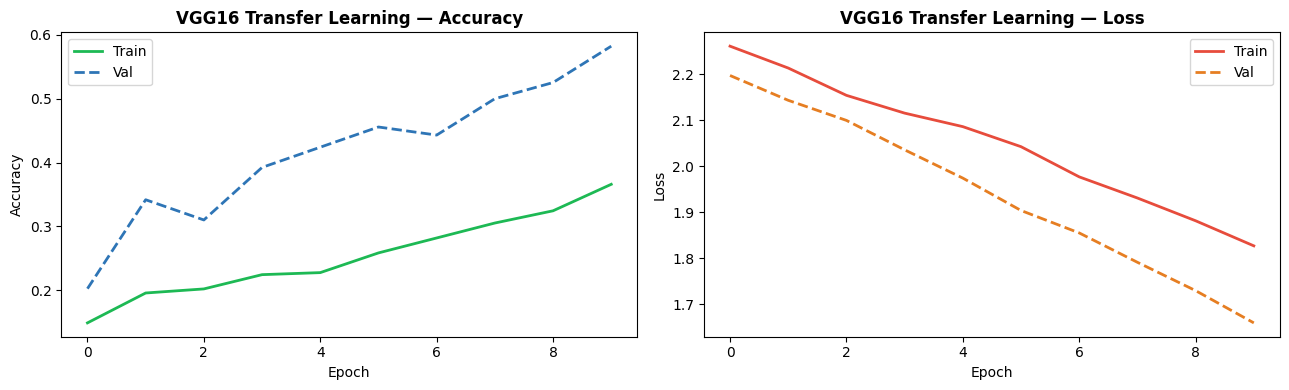


=== VGG16 ===
  Accuracy:        0.5588
  Precision (macro): 0.5834
  Recall (macro):    0.5567
  F1 (macro):        0.5376
  AUC (micro OvR):   0.8870


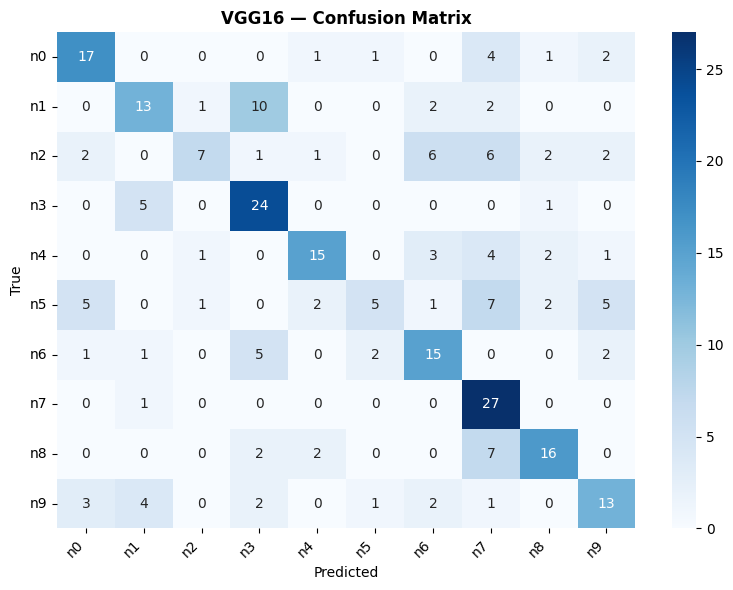

In [34]:
def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False
    inputs = keras.Input((224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x); x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='VGG16_Transfer'), base

vgg, vgg_base = build_vgg16()
vgg.compile(optimizer=keras.optimizers.Adam(LR_TL),
            loss='categorical_crossentropy', metrics=['accuracy'])

vgg_cb = [callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor='val_loss'),
          callbacks.ModelCheckpoint('best_vgg16.keras', monitor='val_accuracy', save_best_only=True)]

print('VGG16 Phase 1 (frozen base)...')
vgg.fit(train_generator, validation_data=val_generator, epochs=5, callbacks=vgg_cb, verbose=1)

print('\nVGG16 Phase 2 (fine-tune last 4 layers)...')
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
vgg.compile(optimizer=keras.optimizers.Adam(1e-5),
            loss='categorical_crossentropy', metrics=['accuracy'])
vgg_hist = vgg.fit(train_generator, validation_data=val_generator,
                   epochs=EPOCHS_TL, callbacks=vgg_cb, verbose=1)
plot_training_curves(vgg_hist, 'VGG16 Transfer Learning')
vgg_results = evaluate_model(vgg, test_generator, 'VGG16')

## Step 8: Model 3 — ResNet50 (transfer learning, two-stage)

ResNet50 Phase 1 (frozen base)...
Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.0915 - loss: 2.5626 - val_accuracy: 0.1139 - val_loss: 2.3078
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 918ms/step - accuracy: 0.1021 - loss: 2.4484 - val_accuracy: 0.1203 - val_loss: 2.2995
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 876ms/step - accuracy: 0.0904 - loss: 2.4068 - val_accuracy: 0.1203 - val_loss: 2.2907
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 905ms/step - accuracy: 0.1181 - loss: 2.3588 - val_accuracy: 0.1392 - val_loss: 2.2808
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 864ms/step - accuracy: 0.1138 - loss: 2.3307 - val_accuracy: 0.1139 - val_loss: 2.2813

ResNet50 Phase 2 (fine-tune last 10 layers)...
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.1170 - loss: 2.2920 - val_accuracy: 0.1456 - val_loss: 2.2771
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 915ms/step - accuracy: 0.1606 - loss: 2.2584 - val_accuracy: 0.1582 - val_loss: 2.2747
Epoch 3/10
30/30 ━━━━━━━━━

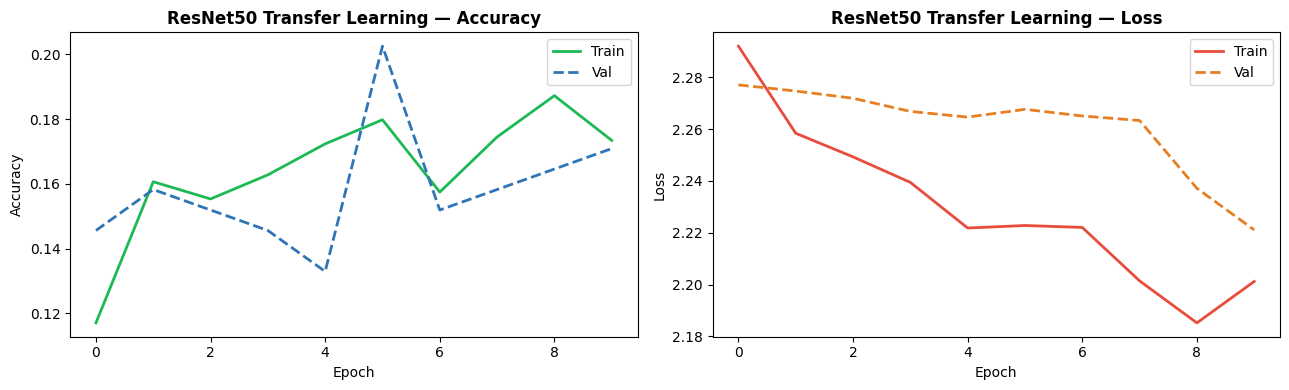


=== ResNet50 ===
  Accuracy:        0.1618
  Precision (macro): 0.1627
  Recall (macro):    0.1663
  F1 (macro):        0.0872
  AUC (micro OvR):   0.6000


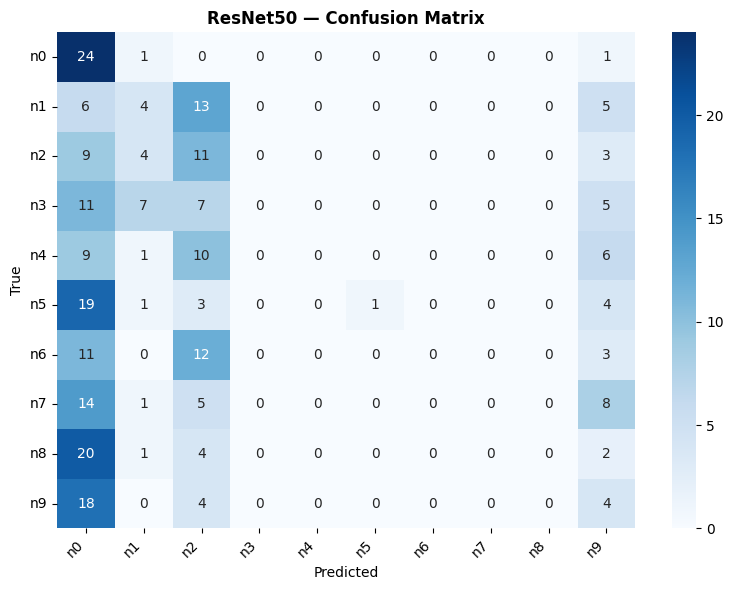

In [35]:
def build_resnet50():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False
    inputs = keras.Input((224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x); x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='ResNet50_Transfer'), base

resnet, resnet_base = build_resnet50()
resnet.compile(optimizer=keras.optimizers.Adam(LR_TL),
               loss='categorical_crossentropy', metrics=['accuracy'])

resnet_cb = [callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor='val_loss'),
             callbacks.ModelCheckpoint('best_resnet50.keras', monitor='val_accuracy', save_best_only=True)]

print('ResNet50 Phase 1 (frozen base)...')
resnet.fit(train_generator, validation_data=val_generator, epochs=5, callbacks=resnet_cb, verbose=1)

print('\nResNet50 Phase 2 (fine-tune last 10 layers)...')
resnet_base.trainable = True
for layer in resnet_base.layers[:-10]:
    layer.trainable = False
resnet.compile(optimizer=keras.optimizers.Adam(1e-5),
               loss='categorical_crossentropy', metrics=['accuracy'])
resnet_hist = resnet.fit(train_generator, validation_data=val_generator,
                         epochs=EPOCHS_TL, callbacks=resnet_cb, verbose=1)
plot_training_curves(resnet_hist, 'ResNet50 Transfer Learning')
resnet_results = evaluate_model(resnet, test_generator, 'ResNet50')

## Step 9: Model Comparison — Metrics Table & ROC Curves

=== MODEL COMPARISON ===
     model  accuracy  precision   recall  f1_score      auc
Custom CNN  0.110294   0.048653 0.108205  0.057083 0.539639
     VGG16  0.558824   0.583353 0.556669  0.537584 0.887027
  ResNet50  0.161765   0.162719 0.166290  0.087163 0.599995


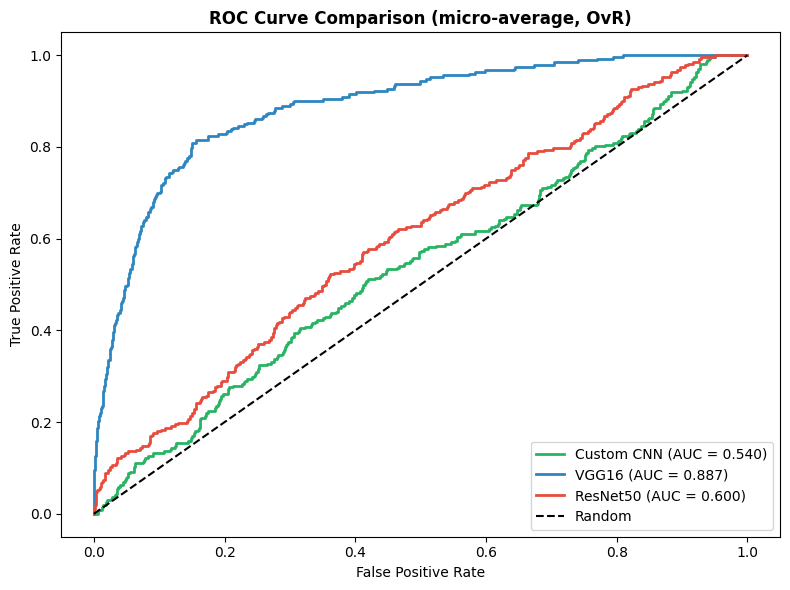

In [36]:
results = [cnn_results, vgg_results, resnet_results]
comp = pd.DataFrame([{k: r[k] for k in ['model','accuracy','precision','recall','f1_score','auc']}
                     for r in results])
print('=== MODEL COMPARISON ===')
print(comp.to_string(index=False))
comp.to_csv('model_comparison.csv', index=False)

# Micro-average ROC (one-vs-rest) for each model
plt.figure(figsize=(8,6))
colors = {'Custom CNN':'#28B463','VGG16':'#2E86C1','ResNet50':'#E74C3C'}
for r in results:
    y_bin = label_binarize(r['y_true'], classes=range(NUM_CLASSES))
    fpr, tpr, _ = roc_curve(y_bin.ravel(), r['y_prob'].ravel())
    plt.plot(fpr, tpr, lw=2, color=colors[r['model']],
             label=f"{r['model']} (AUC = {auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (micro-average, OvR)', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=120, bbox_inches='tight'); plt.show()

## Step 10: Computational Efficiency

In [37]:
def model_size_mb(model):
    params = model.count_params()
    return params * 4 / (1024**2)  # 4 bytes per float32 param

rows = []
for name, model in [('Custom CNN', cnn), ('VGG16', vgg), ('ResNet50', resnet)]:
    total = model.count_params()
    trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
    # inference time over a few batches
    test_generator.reset()
    xb, _ = next(test_generator)
    times = []
    for _ in range(10):
        t0 = time.time(); model.predict(xb, verbose=0); times.append((time.time()-t0)/len(xb)*1000)
    rows.append({'Model': name, 'Total Params': total, 'Trainable': int(trainable),
                 'Size (MB)': round(model_size_mb(model),2),
                 'Inference (ms/img)': f'{np.mean(times):.2f} ± {np.std(times):.2f}'})

eff = pd.DataFrame(rows)
print('=== EFFICIENCY ===')
print(eff.to_string(index=False))
eff.to_csv('model_efficiency.csv', index=False)

=== EFFICIENCY ===
     Model  Total Params  Trainable  Size (MB) Inference (ms/img)
Custom CNN        527050     526090       2.01        4.55 ± 5.11
     VGG16      14880202    7244938      56.76        6.75 ± 5.96
  ResNet50      24146442    5024394      92.11      18.11 ± 42.24


## Step 11: Explainability — Grad-CAM
We overlay Grad-CAM heatmaps on test images for the **best model** to confirm it focuses on the animal rather than the background.

Best model for Grad-CAM: VGG16


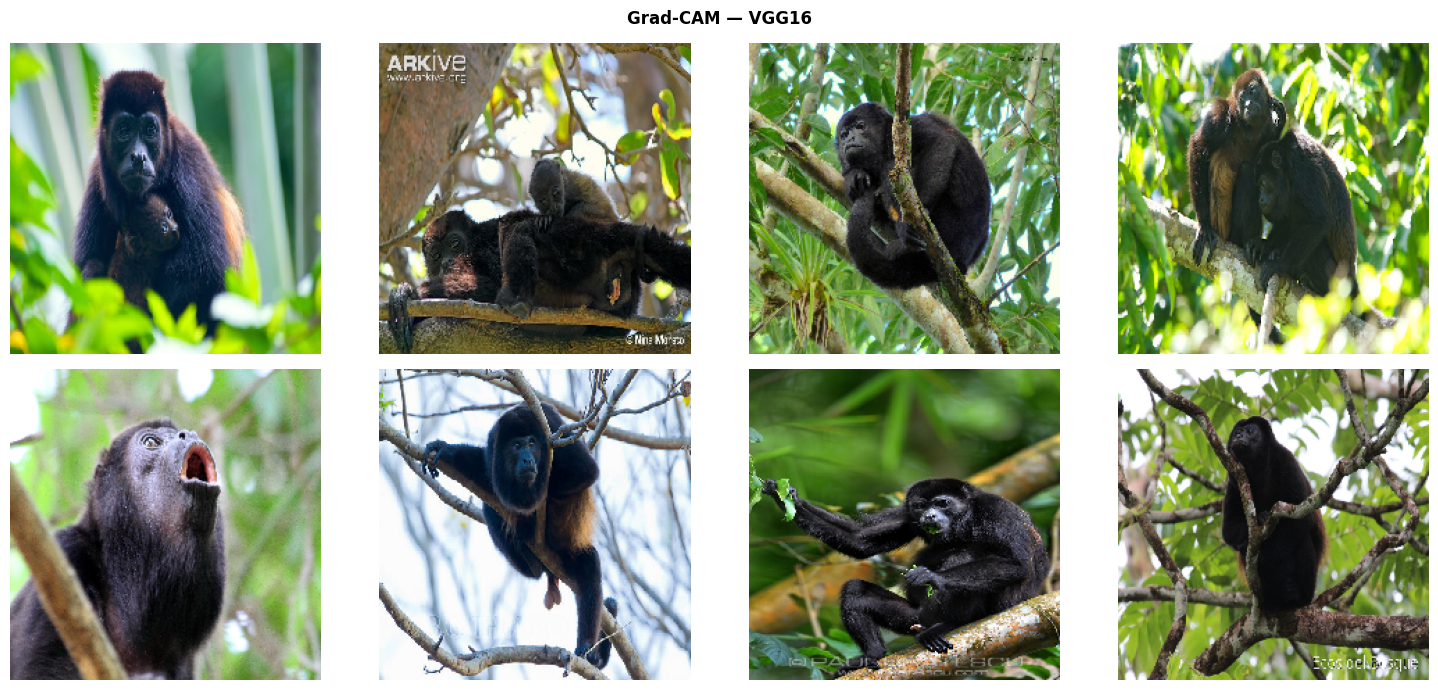

In [38]:
def make_gradcam(model, img_array, last_conv_layer_name):
    grad_model = keras.Model(model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(class_idx)

# Pick the best model by accuracy
best = max(results, key=lambda r: r['accuracy'])['model']
best_model = {'Custom CNN':cnn,'VGG16':vgg,'ResNet50':resnet}[best]
print('Best model for Grad-CAM:', best)

# Find last conv layer name in the best model
def last_conv_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, keras.Model):  # nested base (VGG/ResNet)
            for l in reversed(layer.layers):
                if 'conv' in l.name.lower(): return layer.name  # use nested model output instead
        if 'conv' in layer.name.lower():
            return layer.name
    return None

import cv2
test_generator.reset()
xb, yb = next(test_generator)
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, ax in enumerate(axes.ravel()):
    img = xb[i:i+1]
    try:
        # for transfer models the conv layers live inside the base model;
        # fall back to Custom CNN style if needed
        lname = None
        for layer in reversed(best_model.layers):
            if 'conv' in layer.name.lower():
                lname = layer.name; break
        if lname is None:
            ax.imshow(xb[i]); ax.axis('off'); continue
        heat, cls = make_gradcam(best_model, img, lname)
        heat = cv2.resize(heat, IMG_SIZE)
        ax.imshow(xb[i]); ax.imshow(heat, cmap='jet', alpha=0.4)
        ax.set_title(f'Pred: {CLASSES[cls]}', fontsize=9)
    except Exception as e:
        ax.imshow(xb[i]); ax.set_title('(raw)', fontsize=9)
    ax.axis('off')
plt.suptitle(f'Grad-CAM — {best}', fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam.png', dpi=120, bbox_inches='tight'); plt.show()

## Step 12: Summary

- Three models (Custom CNN, VGG16, ResNet50) were trained on the 10 Monkey Species dataset under identical conditions.
- Transfer-learning models are expected to outperform the from-scratch CNN on this small dataset.
- Metrics (accuracy, macro precision/recall/F1, AUC), confusion matrices, ROC curves, efficiency, and Grad-CAM are all produced above.
- See `model_comparison.csv` and `model_efficiency.csv` for the saved result tables.

**Saved figures:** class_distribution.png, sample_images.png, *_curves.png, *_confusion.png, roc_comparison.png, gradcam.png